#### Tutorial and Lab 5

Step 1. Import pandas, numpy and scipy

In [102]:
import pandas as pd
import numpy as np
import scipy as scp

Step 2. import IRIS Dataset using requests
http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

In [104]:
import requests
iris = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
d = requests.get(iris)

In [106]:
with open("irisdata.csv", 'w') as f:
    f.write(d.text)


Step 3. Convert the data into pandas dataframe

In [108]:
df1 = pd.read_csv("irisdata.csv")
df1.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "flower_class"]
df1 = df1.sample(frac=1).reset_index(drop=True)

In [110]:
oneh_iris = {"setosa":(1,0,0), "versicolor":(0,1,0), "virginica":(0,0,1)}
enc  = {"Iris-setosa":2, "Iris-versicolor":1, "Iris-virginica":0}

Step 4. Assign names to the columns and then give them classes.

In [112]:
#Try these out.
zero_col = [0]*len(df1)
df2 = df1[df1.columns[:4]]
len(df2), len(zero_col)
print(df1)

     sepal_length  sepal_width  petal_length  petal_width     flower_class
0             7.7          2.6           6.9          2.3   Iris-virginica
1             5.4          3.4           1.5          0.4      Iris-setosa
2             5.6          2.9           3.6          1.3  Iris-versicolor
3             7.2          3.2           6.0          1.8   Iris-virginica
4             7.3          2.9           6.3          1.8   Iris-virginica
..            ...          ...           ...          ...              ...
144           5.7          3.8           1.7          0.3      Iris-setosa
145           5.8          2.7           3.9          1.2  Iris-versicolor
146           6.7          2.5           5.8          1.8   Iris-virginica
147           5.0          3.6           1.4          0.2      Iris-setosa
148           4.9          3.0           1.4          0.2      Iris-setosa

[149 rows x 5 columns]


**Task 1.** Split the dataframe into train and test sets: (X_tr,y_tr) and (X_ts,y_ts).


In [114]:
from sklearn.model_selection import train_test_split

# Assuming 'df1' is your DataFrame and 'flower_class' is the target column
X = df1[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]  # Features
y = df1['flower_class']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
from sklearn.neighbors import KNeighborsClassifier
#Train the classifier.
neighb = KNeighborsClassifier(n_neighbors=3)
neighb.fit(X_tr,y_tr)


KNeighborsClassifier(n_neighbors=3)

In [118]:
y_pred = neighb.predict(X_ts)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_ts, y_pred)
print(f"Accuracy: {accuracy}")

from sklearn.metrics import classification_report
print(classification_report(y_ts, y_pred))

Accuracy: 0.9666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        30
      macro avg       0.98      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [120]:
input_example = np.array([[6.3, 3, 4.5, 1.5]])  # Example input
prediction = neighb.predict(input_example)
print(f"Prediction: {prediction[0]}")

Prediction: Iris-versicolor


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


**Task 2.** Choose the two features *sepal_length* and *sepal_width* and plot them using **matplotlib**.

/var/folders/w5/nyp7f5y53w53xb69z47g2g3h0000gn/T/ipykernel_2451/4145442602.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df1['sepal_length'], df1['sepal_width'], cmap='viridis')


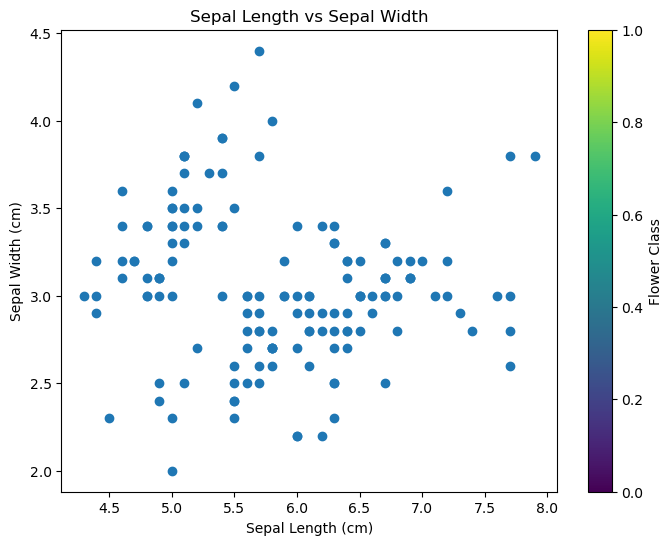

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))  # Adjust figure size if needed

# Scatter plot of sepal_length vs sepal_width
plt.scatter(df1['sepal_length'], df1['sepal_width'], cmap='viridis')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')

# Optionally, add a colorbar to show the flower class mapping
plt.colorbar(label='Flower Class')

plt.show()

/var/folders/w5/nyp7f5y53w53xb69z47g2g3h0000gn/T/ipykernel_2451/1461462376.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df1['petal_length'], df1['petal_width'], cmap='viridis')


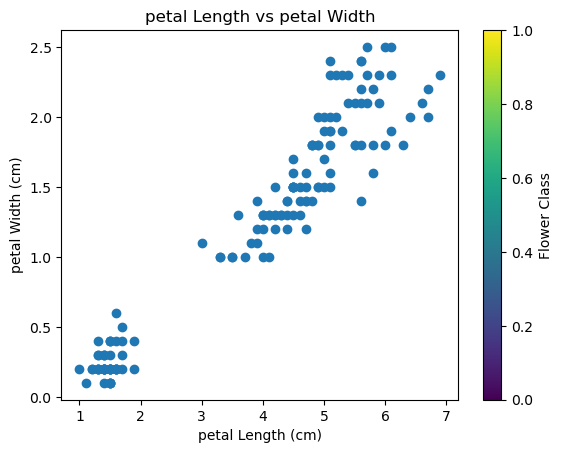

In [133]:
# Scatter plot of sepal_length vs sepal_width
plt.scatter(df1['petal_length'], df1['petal_width'], cmap='viridis')

plt.xlabel('petal Length (cm)')
plt.ylabel('petal Width (cm)')
plt.title('petal Length vs petal Width')

# Optionally, add a colorbar to show the flower class mapping
plt.colorbar(label='Flower Class')

plt.show()

In [135]:
# Tutorial 6


import seaborn as sns
import matplotlib.pyplot as plt


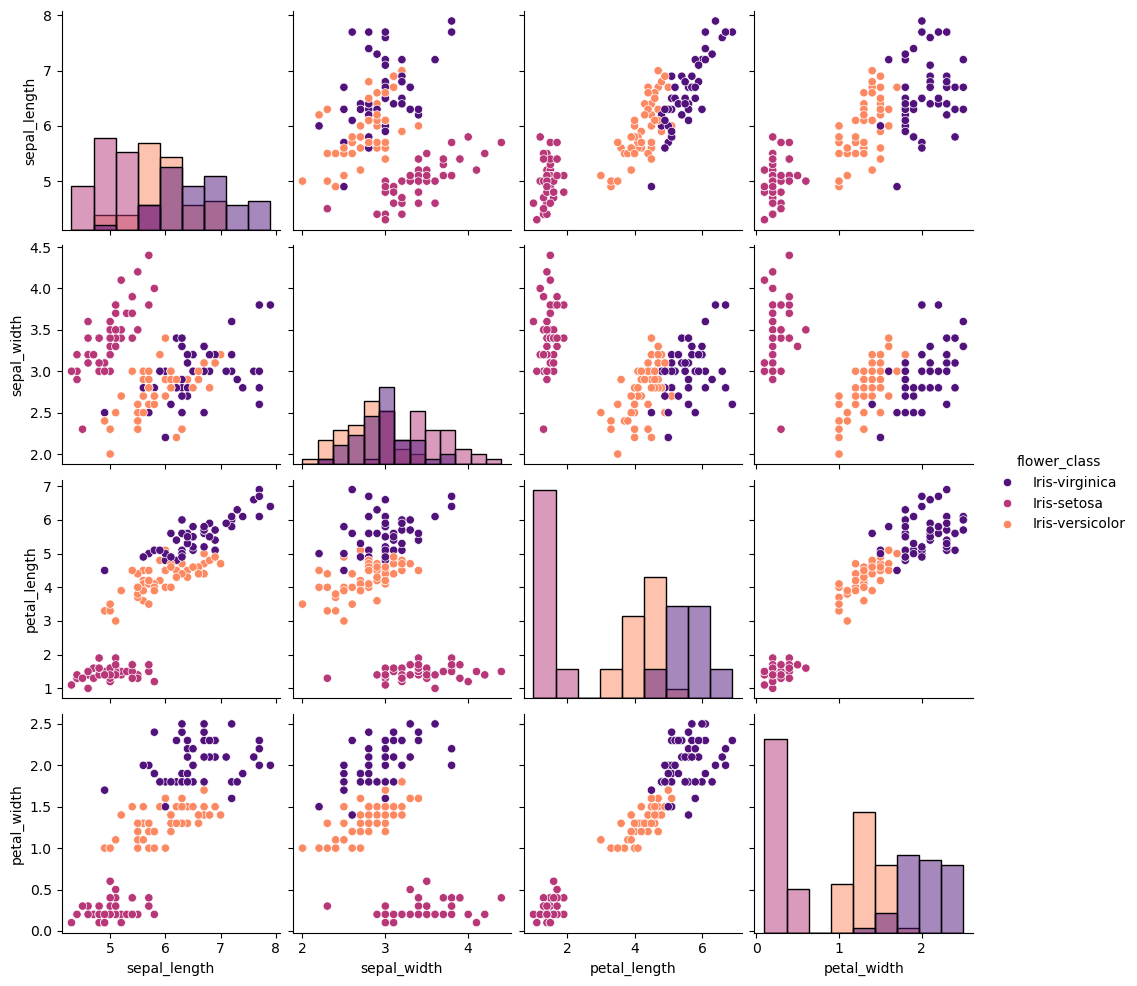

In [137]:
sns.pairplot(df1,hue='flower_class', palette='magma',diag_kind='hist')
plt.show()

In [139]:
from sklearn.decomposition import PCA


In [141]:
pca = PCA(n_components=3)

In [145]:
iris_df1 = df1.drop('flower_class',axis =1)

In [149]:
pca.fit(iris_df1)
iris_df1 = pca.transform(iris_df1)
iris_df1

array([[ 3.77710179,  0.24961889, -0.51682901],
       [-2.42744251,  0.42388348, -0.13888805],
       [-0.19326273, -0.24930664,  0.09356972],
       [ 2.59703873,  0.55659104, -0.20848527],
       [ 2.91455996,  0.35005959, -0.42366214],
       [ 1.39516536, -0.57474647,  0.29655609],
       [ 0.6410186 , -0.35065097,  0.32840383],
       [-2.66443393,  0.82625736,  0.22994322],
       [ 1.09805709, -0.08353883,  0.45982882],
       [ 0.91488037,  0.3200081 , -0.01728155],
       [ 1.42488684, -0.14379794, -0.15404983],
       [ 1.56638355, -0.53929124,  0.63073514],
       [ 0.92358198, -0.54117049, -0.49724476],
       [-2.6511475 , -0.18387812,  0.0461236 ],
       [ 2.29653466,  0.18143615,  0.3228819 ],
       [ 2.37028851,  0.46101268, -0.45207928],
       [ 1.27799588, -0.32739624, -0.34743941],
       [-2.88487621,  0.08368008, -0.15728558],
       [ 0.33676147, -0.50152775,  0.01792476],
       [-3.00058136, -0.47351799,  0.07943439],
       [ 1.32538608, -0.77613761,  0.283

In [169]:
iris_df2 = pd.DataFrame(iris_df1,columns=['pca1','pca2','pca3'])

In [171]:
iris_df2['flower_class'] = df1['flower_class'].values

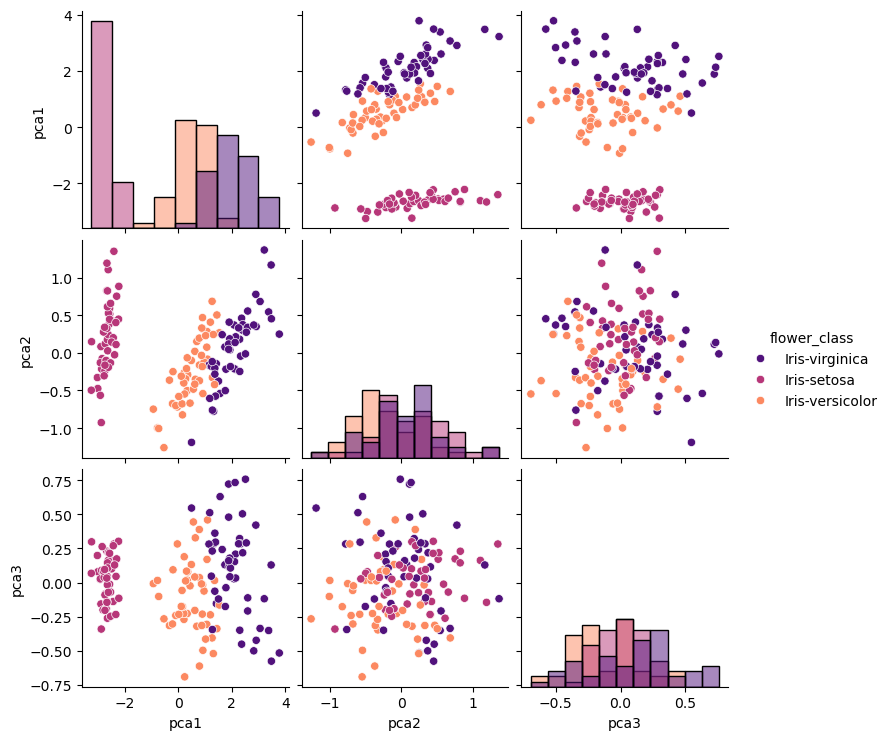

In [173]:
sns.pairplot(iris_df2,hue='flower_class', palette='magma',diag_kind='hist')
plt.show()